Download packages if running for the very 1st time  ;)

should only take 5min tops

In [1]:
using Pkg
Pkg.add("Images")
Pkg.add("FileIO")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
using Images, FileIO, LinearAlgebra, Statistics

Load your image (change the name).

In [3]:
img1 = load("img1.webp")
typeof(img1), size(img1)

(Matrix{RGB{N0f8}}, (896, 1280))

Convert to greyscale and SVD the image matrix.

In [4]:
greyscale = Float64.(Gray.(img1)) #svd() dela sm na floatih
U, S, V = svd(greyscale)

SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}
U factor:
896×896 Matrix{Float64}:
 0.0539541  -0.0253778    0.0602461  …   0.0254967    -0.0229894
 0.0540085  -0.0254512    0.0602173     -0.101983      0.0717754
 0.0541371  -0.025355     0.0601949      0.0641113    -0.0773573
 0.0541189  -0.0254113    0.0596955     -0.0208228     0.0633392
 0.0542324  -0.0256636    0.0601334      0.0564079    -0.0248552
 0.0540656  -0.0255341    0.0598926  …  -0.0589505     0.0131714
 0.0541611  -0.0255201    0.0603024      0.0840824    -0.0070261
 0.0541102  -0.0254274    0.0603127     -0.0348882     0.000737895
 0.0519711  -0.0242619    0.0679786     -0.0170341    -0.0165963
 0.0463868  -0.0189036    0.0860714      0.00512921   -0.00616874
 0.0437406  -0.0110156    0.0935149  …  -0.0136461    -0.00836274
 0.0421091  -0.00518356   0.0970349      0.0267331     0.0204879
 0.0414842  -0.00235118   0.0984193     -0.00639771   -0.0436019
 ⋮                                   ⋱                 ⋮
 0.

Choose r-number of singular values and construct their SVD image.

In [5]:
images = []
err = []

for r in 1:5:50
    Ur = U[:, 1:r]
    Sr = Diagonal(S[1:r])
    Vr = V[:, 1:r]
    recon = Ur * Sr * transpose(Vr)
    recon =Gray.(recon)
    push!(images,recon)
    # mean absolute error over all pixels
    e = mean(abs.(greyscale .- recon))
    push!(err,round(Float64(e),digits=5))
end
print("Error percentage for each image:\n")
err


Error percentage for each image:


10-element Vector{Any}:
 0.14662
 0.0734
 0.05761
 0.04935
 0.04299
 0.03735
 0.03373
 0.03078
 0.02832
 0.02633

Look at the cool images :D 

*(rows x cols must equal the number of images efcourse)*

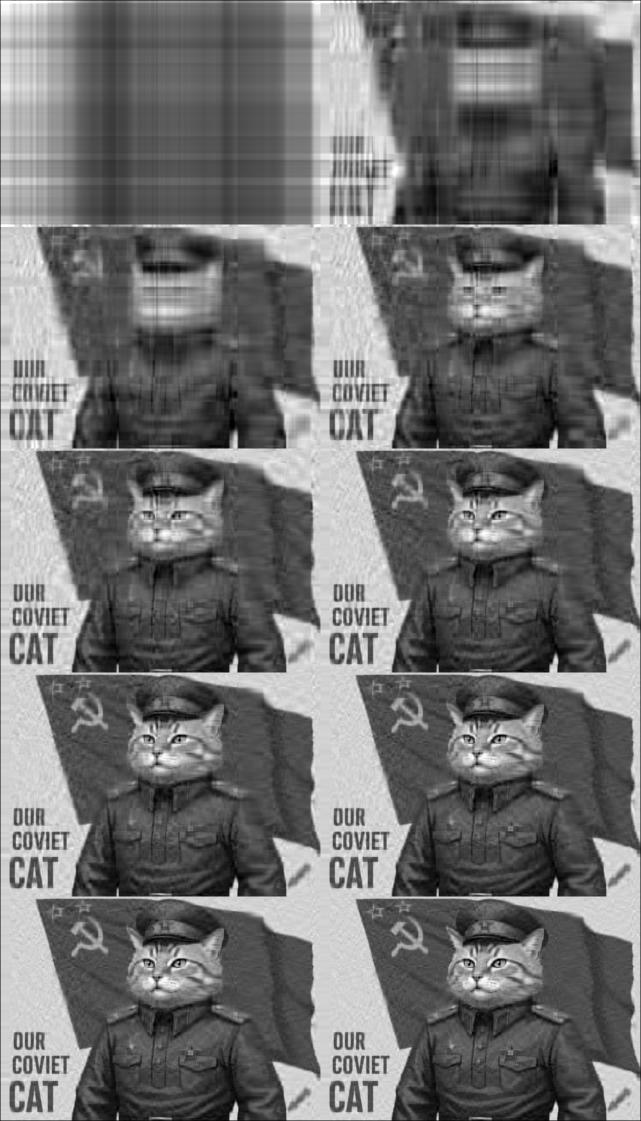

In [6]:
# rows*cols == size(images) !!!!!
rows = 5
cols = 2
row_images = [hcat(images[(r-1)*cols + 1 : r*cols]...) for r in 1:rows]
display(vcat(row_images...))